<a href="https://colab.research.google.com/github/NegasaReta/Elevvo-Internship-Machine-Learning-Track/blob/Task-2/Task2_Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import the important Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

##Load the dataset

In [4]:
try:
    df = pd.read_csv('/content/Mall_Customers.csv')
    print("Dataset loaded successfully.")
    print("-" * 30)
    print(df.head())
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found. Please upload the file to the Colab files section.")

Dataset loaded successfully.
------------------------------
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

## Select features for clustering
##We typically use Annual Income and Spending Score for 2D visualization

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

## 2. DATA PREPROCESSING (SCALING)

#Standardizing the data is important for K-Means to ensure features are on the same scale

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##3. ELBOW METHOD (FIND OPTIMAL K)

In [8]:
# We calculate the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


# Plot the Elbow Graph

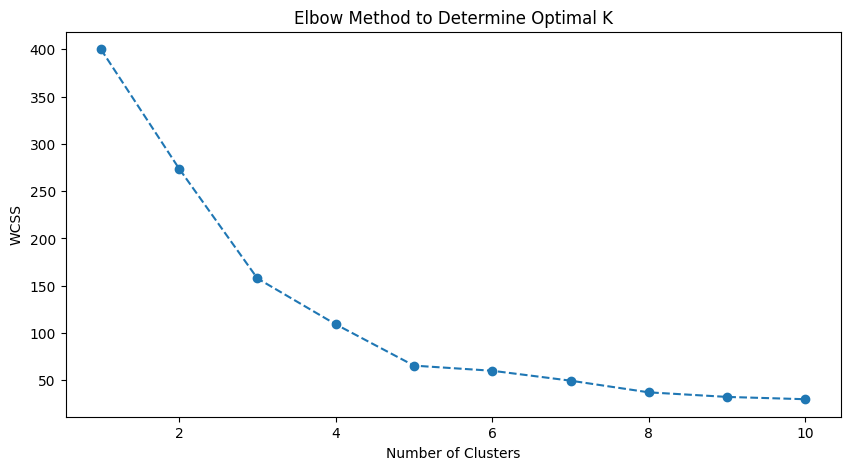

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## 4. APPLY K-MEANS CLUSTERING

Based on the typical Mall Dataset, the elbow usually occurs at K=5

In [11]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

Add the cluster labels back to the original dataframe for interpretation

In [12]:
df['Cluster'] = y_kmeans

## 5. VISUALIZE CLUSTERS

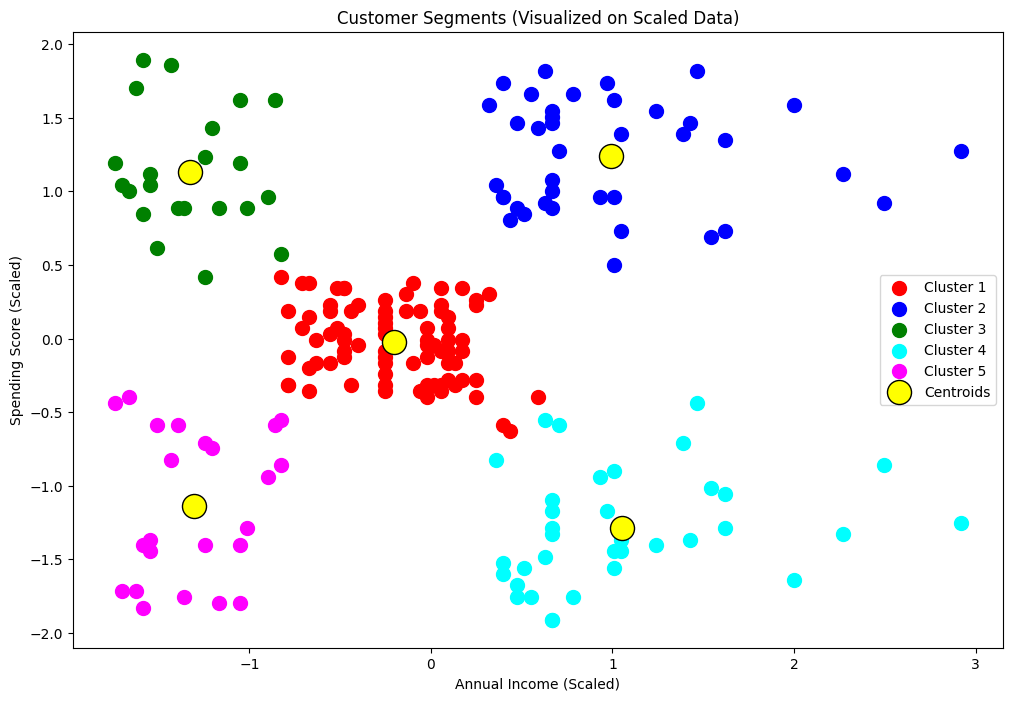

In [23]:
plt.figure(figsize=(12, 8))
# Define colors for the clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

# Plot each cluster
for i in range(optimal_k):
    # We plot the SCALED data points belonging to cluster 'i'
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')
# Plot the Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids', edgecolors='black')
plt.title('Customer Segments (Visualized on Scaled Data)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

##6. CLUSTER ANALYSIS

In [19]:
print("\nCluster Profiling (Mean Values of Original Data):")
# Group by cluster and calculate the mean of the original features
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(profile)


Cluster Profiling (Mean Values of Original Data):
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
